# Iris Flower Classification using Machine Learning

## Horizon Internship Project

### Objective

Develop a machine learning model to classify Iris flowers into their respective species using flower measurements.

### Dataset

The Iris dataset contains measurements of sepal length, sepal width, petal length, and petal width for three different Iris flower species.

### Algorithms Used

- Random Forest Classifier

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Import Libraries

Import the required Python libraries for data analysis, visualization, and machine learning.

In [84]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Load Dataset

Load the Iris dataset into a Pandas DataFrame.

In [85]:
df = pd.read_csv("Iris.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Dataset Overview

Explore the structure of the dataset before performing any analysis.

In [86]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [87]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [88]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 150
Columns : 6


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [90]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## Data Cleaning

Check for missing values, duplicate records, and remove unnecessary columns.

In [91]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [92]:
df.duplicated().sum()

np.int64(0)

In [93]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [94]:
df.drop("Id", axis=1, inplace=True)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the distribution of features, identify relationships between variables, and gain insights before training the machine learning model.


In [95]:
# Display unique flower species

print("Flower Species:")
print(df['Species'].unique())

Flower Species:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [96]:
# Count the number of samples in each species

df['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [97]:
# Correlation matrix for numerical features

df.drop('Species', axis=1).corr()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


## Data Visualization

Visualizations help identify feature distributions, relationships between variables, and differences among Iris flower species.


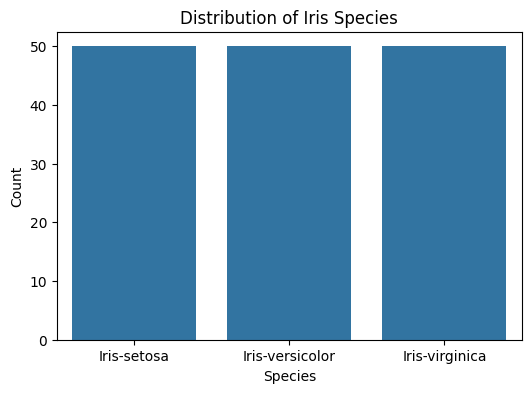

In [98]:
# Count plot for flower species

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Species')

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

### Analysis

The dataset contains an equal number of samples for all three Iris species. This balanced distribution helps prevent bias during model training and improves the reliability of the classification model.


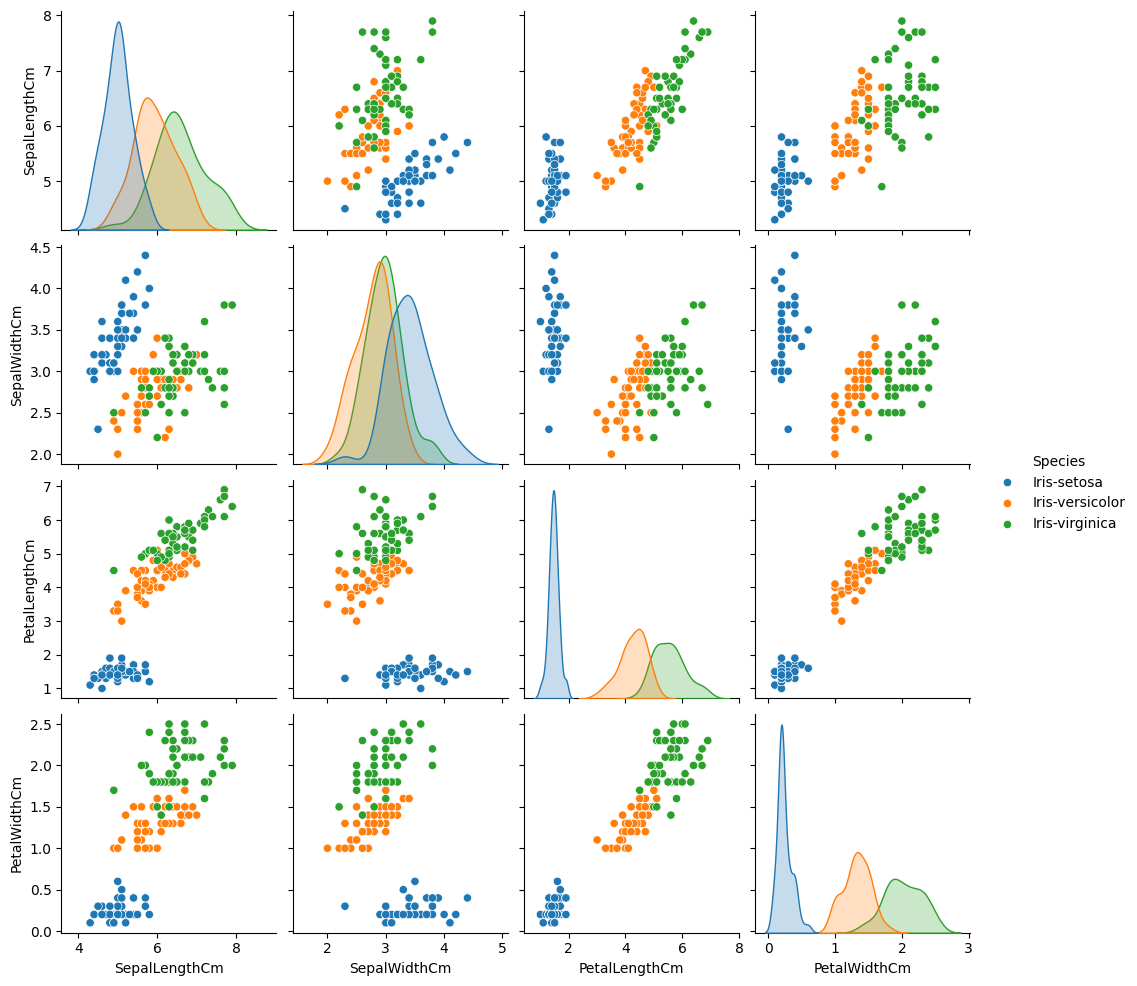

In [99]:
# Pair plot of all numerical features

sns.pairplot(df, hue='Species')

plt.show()

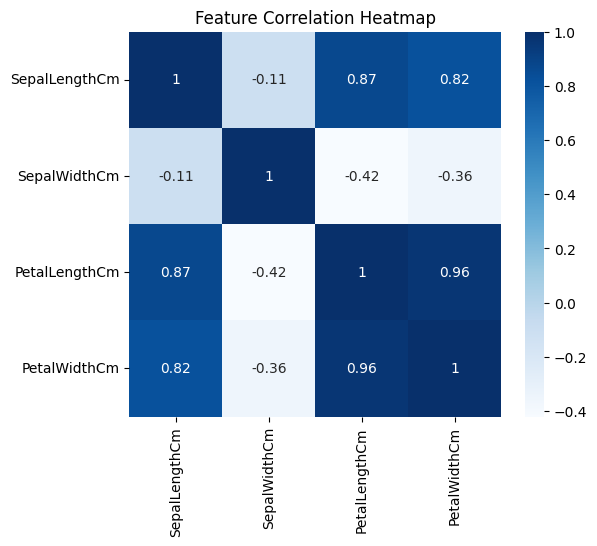

In [100]:
# Heatmap showing correlation between numerical features

plt.figure(figsize=(6,5))

sns.heatmap(
    df.drop('Species', axis=1).corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Analysis

The correlation matrix shows the relationship between numerical features. Petal length and petal width have a strong positive correlation, indicating that these features are closely related and useful for classification.


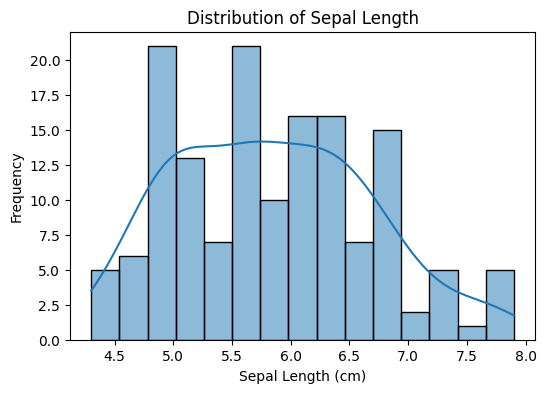

In [101]:
# Distribution of Sepal Length

plt.figure(figsize=(6,4))

sns.histplot(df['SepalLengthCm'], bins=15, kde=True)

plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")

plt.show()

### Analysis

The histogram shows that sepal length values are distributed across a reasonable range with most samples concentrated around the center. No significant outliers are observed.


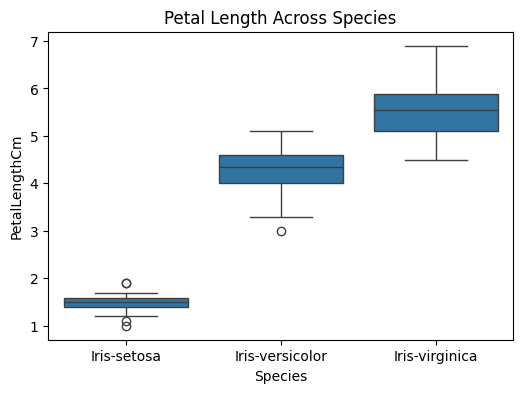

In [102]:
# Box plot of Petal Length by Species

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='Species',
    y='PetalLengthCm'
)

plt.title("Petal Length Across Species")

plt.show()

### Analysis

The box plot demonstrates clear differences in petal length among the three Iris species. Iris Setosa has noticeably smaller petal lengths, making this feature highly effective for distinguishing species.


## Feature Selection

Separate the input features (X) and the target variable (y) before training the machine learning model.


In [103]:
# Input features
X = df.drop('Species', axis=1)

# Target variable
y = df['Species']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (150, 4)
Target Shape : (150,)


## Train-Test Split

Split the dataset into training and testing sets to evaluate the model on unseen data.


In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 105
Testing Samples : 45


## Model Building

A Random Forest Classifier is selected for this project because it is robust, efficient, and performs well on classification tasks.


In [105]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=21
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Model Training

Train the Random Forest model using the training dataset to learn patterns from the input features.


In [106]:
# Train the model

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


## Model Prediction

Use the trained model to predict the species of flowers in the testing dataset.


In [107]:
# Predict test data

y_pred = model.predict(X_test)

y_pred

array(['Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-virginica', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor'], dtype=object)

## Model Evaluation

Evaluate the model using accuracy score, confusion matrix, and classification report.


In [108]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy : {:.2f}%".format(accuracy * 100))

Model Accuracy : 91.11%


### Analysis

The Random Forest model achieved a high accuracy, indicating that it successfully learned the patterns in the Iris dataset and can classify flower species with excellent performance.


In [109]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[15,  0,  0],
       [ 0, 14,  1],
       [ 0,  3, 12]])

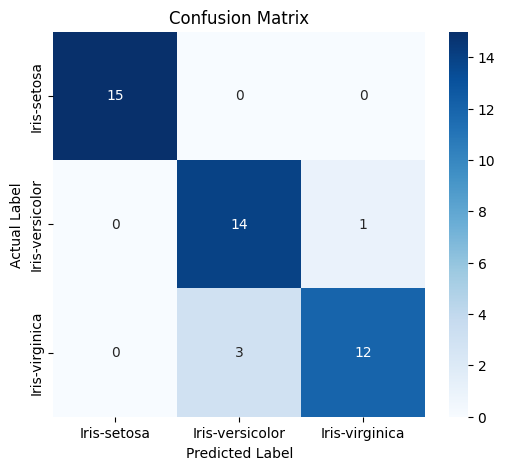

In [110]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Analysis

The confusion matrix shows that most test samples were classified correctly. Very few or no misclassifications indicate that the model performs effectively on the Iris dataset.


In [111]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45



### Analysis

The classification report presents precision, recall, and F1-score for each species. The high values across all metrics demonstrate the strong performance and reliability of the trained model.


## Feature Importance

Feature importance helps identify which flower measurements contributed the most to the model's predictions.


In [112]:
# Create a DataFrame for feature importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Sort values in descending order
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,PetalLengthCm,0.436564
3,PetalWidthCm,0.421508
0,SepalLengthCm,0.115437
1,SepalWidthCm,0.026491


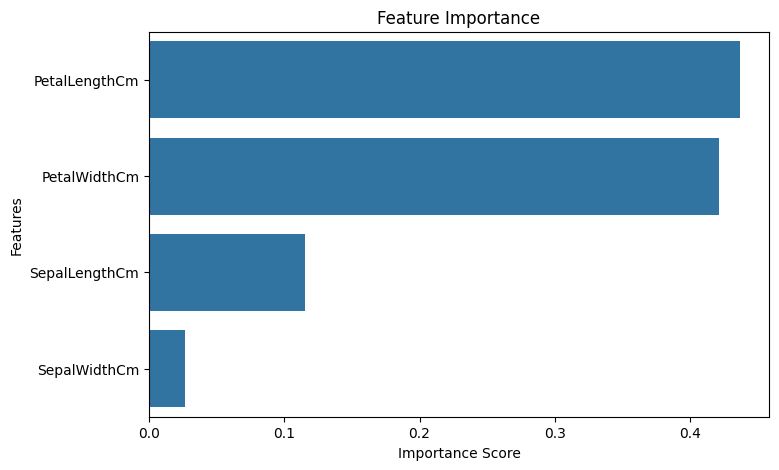

In [113]:
# Plot feature importance

plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

### Analysis

The feature importance plot indicates that petal measurements contribute the most to predicting Iris species. Sepal measurements have comparatively lower importance in the classification process.


## Actual vs Predicted Results

Compare the actual flower species with the model's predictions for a few test samples.


In [114]:
# Compare Actual and Predicted values

comparison = pd.DataFrame({
    'Actual Species': y_test.values,
    'Predicted Species': y_pred
})

comparison.head(10)

,Actual Species,Predicted Species
0,Iris-virginica,Iris-virginica
1,Iris-versicolor,Iris-versicolor
2,Iris-virginica,Iris-versicolor
3,Iris-versicolor,Iris-versicolor
4,Iris-virginica,Iris-virginica
5,Iris-virginica,Iris-virginica
6,Iris-versicolor,Iris-versicolor
7,Iris-versicolor,Iris-versicolor
8,Iris-setosa,Iris-setosa
9,Iris-virginica,Iris-virginica


### Analysis

The comparison table shows that the predicted species closely match the actual species, demonstrating the model's ability to classify unseen samples accurately.


## Prediction on New Sample

Predict the species of a new Iris flower using custom feature values.


In [115]:
# New flower measurements
new_sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_sample)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


### Analysis

The trained model successfully predicts the species of a new flower sample based on its measurements, demonstrating its practical application for classification tasks.


# Conclusion

This project successfully developed a machine learning model to classify Iris flowers using their sepal and petal measurements. After exploring the dataset, performing data visualization, and training a Random Forest Classifier, the model achieved high classification accuracy on the test dataset.

The results demonstrate that petal-related features play a significant role in distinguishing between Iris species. Overall, the project showcases a complete machine learning workflow, including data preprocessing, exploratory data analysis, model training, evaluation, and prediction.


# Future Scope

* Compare the performance of multiple machine learning algorithms.
* Perform hyperparameter tuning to improve model performance.
* Develop a web application for real-time Iris species prediction.
* Deploy the trained model using Flask or Streamlit.
